In [184]:
# Verify library versions
import sys
import os
import tdt
import neurokit2 as nk
from neurokit2 import signal_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import importlib
import h5py
from rsp.plotting import Rsp_Kit
from rsp.data_processing import signal_processing
from scipy.signal import butter, filtfilt, decimate

print("TDT version:", tdt.__version__)
print("NeuroKit2 version:", nk.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

TDT version: 0.6.8
NeuroKit2 version: 0.2.11
NumPy version: 2.3.0
Pandas version: 2.3.0
Matplotlib version: 3.10.3


### For formatting pandas dataframes for longer outputs

In [185]:
pd.set_option('display.max_colwidth', 0)  # 0 means unlimited in newer pandas versions

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column contents
pd.set_option("display.max_colwidth", None)

# Expand the display to the full width of the screen
pd.set_option("display.width", 0)


In [186]:
# reload rsp_kit package to ensure the latest version is used with importlib
import importlib
importlib.reload(Rsp_Kit)
importlib.reload(signal_processing)

<module 'rsp.data_processing.signal_processing' from 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\src\\rsp\\data_processing\\signal_processing.py'>

# Extraction to Plotting Pipeline

In [187]:
h5_path = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"

In [188]:
path1 = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"

### Reading data from h5

In [189]:
# reading h5_path file
try:
    with h5py.File(h5_path, 'r') as f:
        ekg = f['ekg'][:]
        resp = f['resp'][:]

        meta = dict(f['metadata'].attrs)
        ekg_meta = dict(f['ekg_metadata'].attrs)
        resp_meta = dict(f['resp_metadata'].attrs)
        
except Exception as e:
    print(f"Error reading file {h5_path}: {e}")
    sys.exit(1)

In [190]:
# print metadata
print("Metadata:")
for key, value in meta.items():
    print(f"{key}: {value}")
    
# print ekg metadata
print("\nEKG Metadata:")
for key, value in ekg_meta.items():
    print(f"{key}: {value}")
# print resp metadata
print("\nResp Metadata:")
for key, value in resp_meta.items():
    print(f"{key}: {value}")
    

Metadata:
date: 2025-06-21
negative_agent_id: RB3
positive_agent_id: 5.4
subject_id: 3.5
time: 10:50:14
trial_type: RI1

EKG Metadata:
channel_id: 21
duration_sec: 623.73075
num_samples: 12474615
sampling_frequency: 20000.0
stream_id: trodes

Resp Metadata:


In [191]:
# reading path1 file
try:
    with h5py.File(path1, 'r') as f:
        ekg1 = f['ekg'][:]
        resp1 = f['resp'][:]

        meta1 = dict(f['metadata'].attrs)
        ekg_meta = dict(f['ekg_metadata'].attrs)
        resp_meta = dict(f['resp_metadata'].attrs)

except Exception as e:
    print(f"Error reading file {path1}: {e}")
    sys.exit(1)

In [192]:
# print metadata
print("Metadata:")
for key, value in meta.items():
    print(f"{key}: {value}")

# print metadata for resp and ekg
print("\nRespiratory Metadata:")
for key, value in resp_meta.items():
    print(f"{key}: {value}")
print("\nEKG Metadata:")
for key, value in ekg_meta.items():
    print(f"{key}: {value}")
    

Metadata:
date: 2025-06-21
negative_agent_id: RB3
positive_agent_id: 5.4
subject_id: 3.5
time: 10:50:14
trial_type: RI1

Respiratory Metadata:

EKG Metadata:
channel_id: 21
duration_sec: 606.2861
num_samples: 12125722
sampling_frequency: 20000.0
stream_id: trodes


### Quick Plot of Raw Signal


📊 Data Overview:
- EKG shape: (12474615,), dtype: int16
- Resp shape: (12474615, 1), dtype: float64
- Metadata keys: ['date', 'negative_agent_id', 'positive_agent_id', 'subject_id', 'time', 'trial_type']


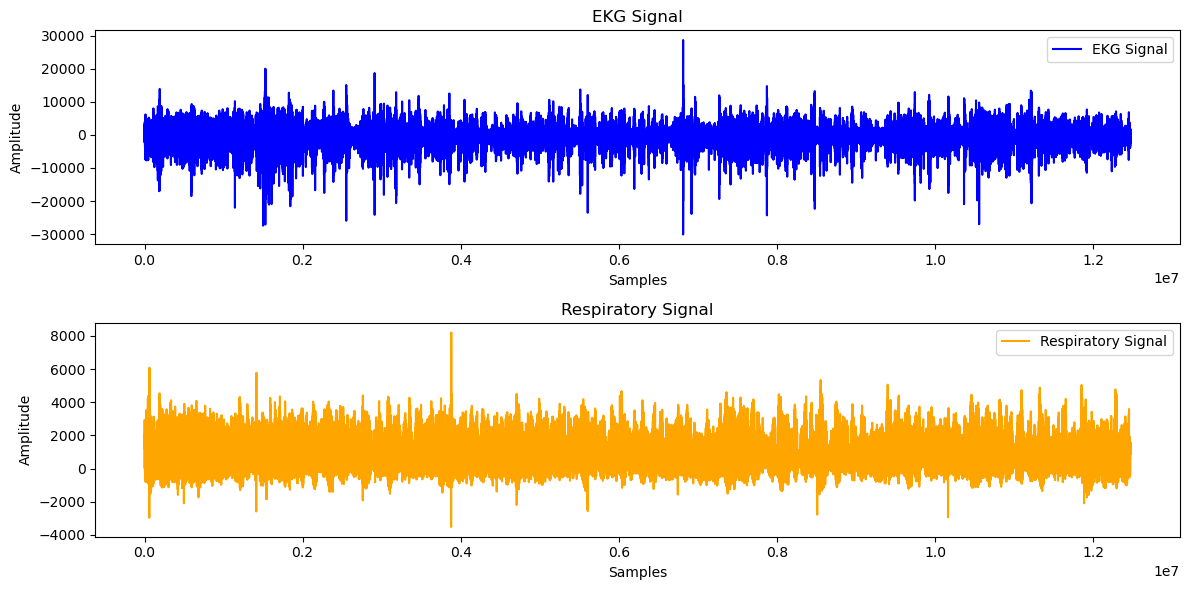

In [193]:
# explore the data
print("\n📊 Data Overview:"
      f"\n- EKG shape: {ekg.shape}, dtype: {ekg.dtype}"
      f"\n- Resp shape: {resp.shape}, dtype: {resp.dtype}"
      f"\n- Metadata keys: {list(meta.keys())}")
# Plot EKG and Resp signals
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(ekg, label='EKG Signal', color='blue')
plt.title('EKG Signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(resp, label='Respiratory Signal', color='orange')
plt.title('Respiratory Signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.show()

### Defining Necessary Data for Dataframe Creation

In [194]:
n_samples = resp.shape[0]
sampling_frequency = 2000 # Assuming a sampling frequency of 2000 Hz

print(f"\nTotal samples in respiratory signal: {n_samples}")
print(f"Sampling frequency: {sampling_frequency} Hz")


Total samples in respiratory signal: 12474615
Sampling frequency: 2000 Hz


In [195]:
resp = resp.flatten()

In [196]:
resp_df = Rsp_Kit.Rsp_Kit(resp, fs=sampling_frequency, size=n_samples)
resp_df.df.head(20)

,Timestamps,Respiration Value,Behavioral Event,Peaks
0,0.0000,1248.0,None,1248.0
1,0.0005,1248.0,None,NaN
2,0.0010,1248.0,None,1248.0
3,0.0015,1272.0,None,1272.0
4,0.0020,1256.0,None,1256.0
5,0.0025,1264.0,None,NaN
6,0.0030,1272.0,None,1272.0
7,0.0035,1272.0,None,1272.0
8,0.0040,1280.0,None,1280.0
9,0.0045,1280.0,None,NaN


C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\rsp\plotting\Rsp_Kit.py:415: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.


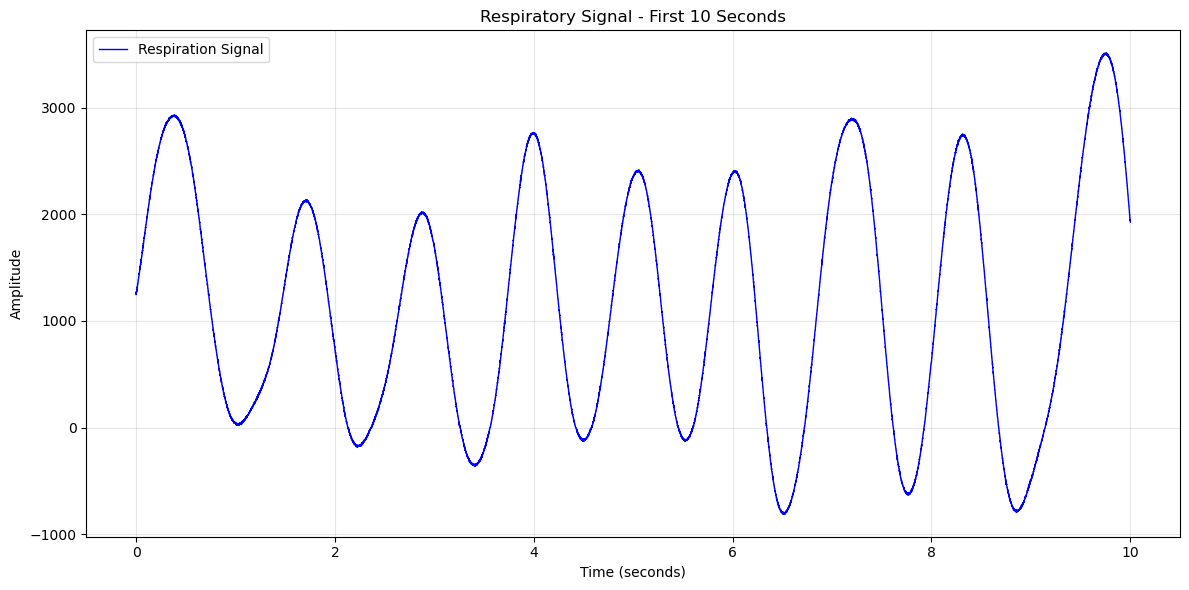

In [197]:
resp_df.plot(duration=10)

### LowPass Filter Before Downsampling Mandatory

In [198]:
target_rate = 250 # new sampling frequency

# Butterworth low-pass filter
cutoff_hz = target_rate / 2  # cutoff just below new Nyquist (125 Hz)
nyquist = sampling_frequency / 2
norm_cutoff = cutoff_hz / nyquist  # normalize to [0,1]
b, a = butter(N=4, Wn=norm_cutoff, btype='low')

# Apply zero-phase filtering
filtered_resp = filtfilt(b, a, resp)

### Downsampling

In [199]:
downsample_factor = sampling_frequency // target_rate
downsampled_resp = decimate(filtered_resp, downsample_factor)

In [200]:
new_resp = Rsp_Kit.Rsp_Kit(downsampled_resp, fs=target_rate, size=len(downsampled_resp))
new_resp.df.head(20)

,Timestamps,Respiration Value,Behavioral Event,Peaks
0,0.000,1233.311632,None,1233.311632
1,0.004,1260.184077,None,NaN
2,0.008,1279.107009,None,NaN
3,0.012,1304.481484,None,NaN
4,0.016,1330.708049,None,NaN
5,0.020,1354.015224,None,NaN
6,0.024,1382.590201,None,NaN
7,0.028,1408.015789,None,NaN
8,0.032,1429.928733,None,NaN
9,0.036,1457.453703,None,NaN


## Plots Examples

### Note: Problem with Peak at start of every plot

C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\rsp\plotting\Rsp_Kit.py:415: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.


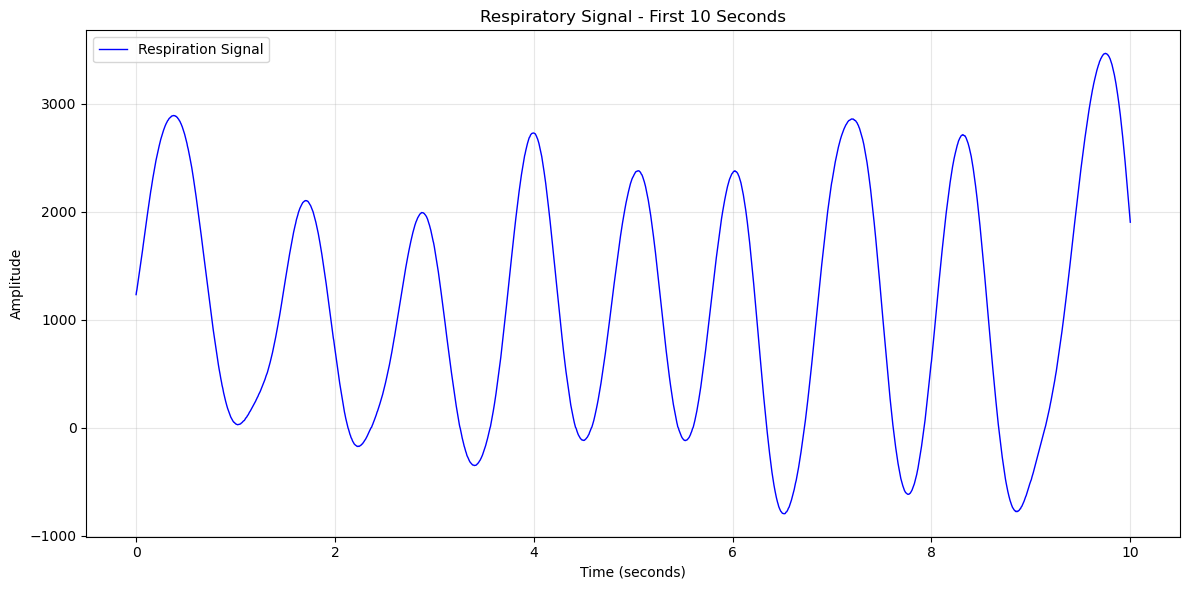

In [201]:
new_resp.plot(duration=10)

### Can Change Duration and Show Peaks

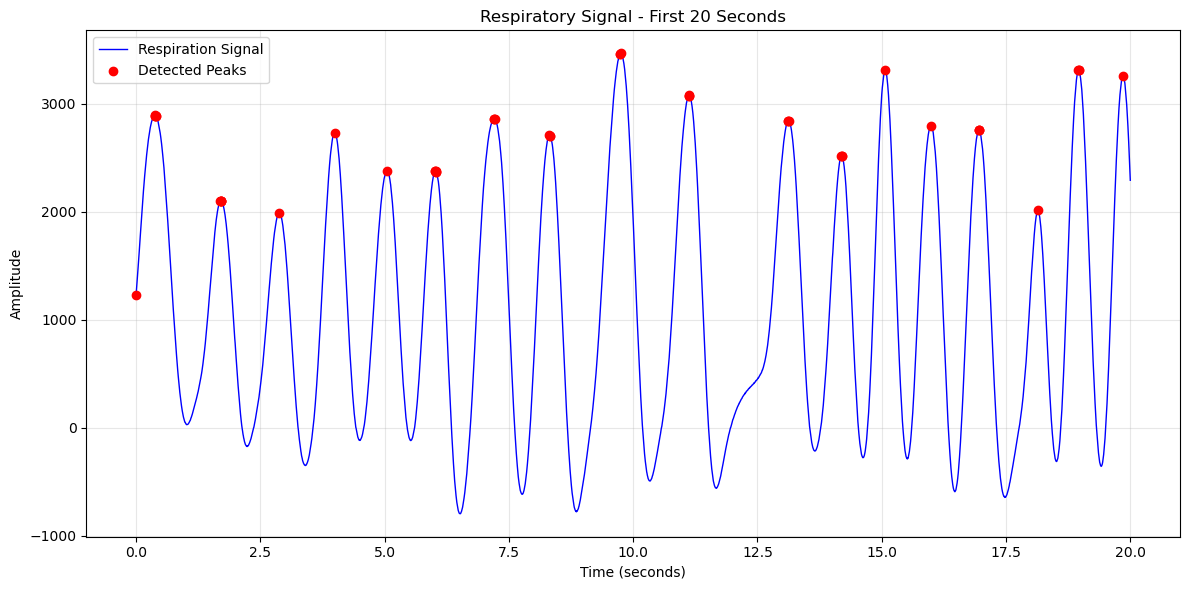

In [202]:
new_resp.plot(duration=20, show_peaks=True)

### Can Change Start Time, will be able to loop through start times of events using this

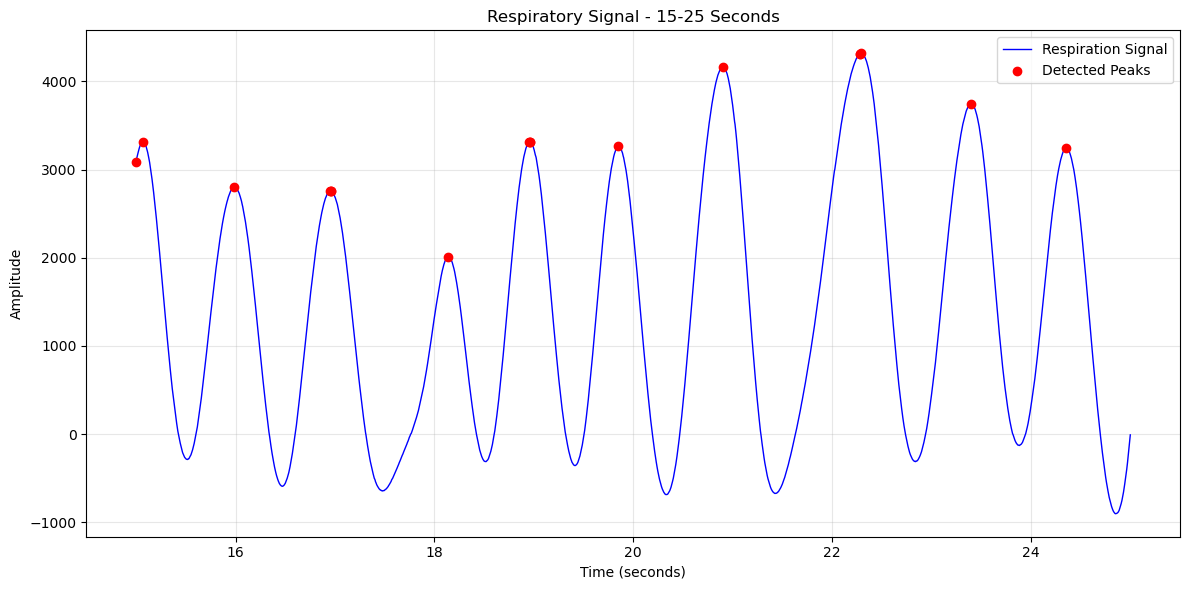

In [203]:
new_resp.plot(start_time=15, duration=10, show_peaks=True)

### Can add behavioral csv to dataframe to plot respiration and events

# Filtering signal loss out

In [204]:
import numpy as np

def filter_signal_loss(
    signal,
    sample_rate = 100,
    long_thresh_sec=3,
    short_thresh_sec=0.5,
    std_thresh=0.01,
    win_sec=0.5,
    stride_sec=0.1
):
    signal = signal.squeeze()  # Ensure shape is (N,), not (N,1)
    win_size = int(win_sec * sample_rate)
    stride = int(stride_sec * sample_rate)
    long_thresh = int(long_thresh_sec * sample_rate)

    bad_windows = []

    for start in range(0, len(signal) - win_size, stride):
        window = signal[start:start + win_size]

        # Skip if all NaN
        if np.isnan(window).all():
            bad_windows.append((start, start + win_size))
        else:
            std = np.nanstd(window)
            if std < std_thresh:
                bad_windows.append((start, start + win_size))

    # Merge overlapping/adjacent windows
    merged_regions = []
    for start, end in sorted(bad_windows):
        if not merged_regions or start > merged_regions[-1][1]:
            merged_regions.append([start, end])
        else:
            merged_regions[-1][1] = max(merged_regions[-1][1], end)

    # Mask long flat stretches with NaN
    for start, end in merged_regions:
        if (end - start) >= long_thresh:
            signal[start:end] = np.nan  # Mark as bad
        # else: keep short flat stretches for later

    return signal


In [205]:
# filtered_resp = filter_signal_loss(resp)

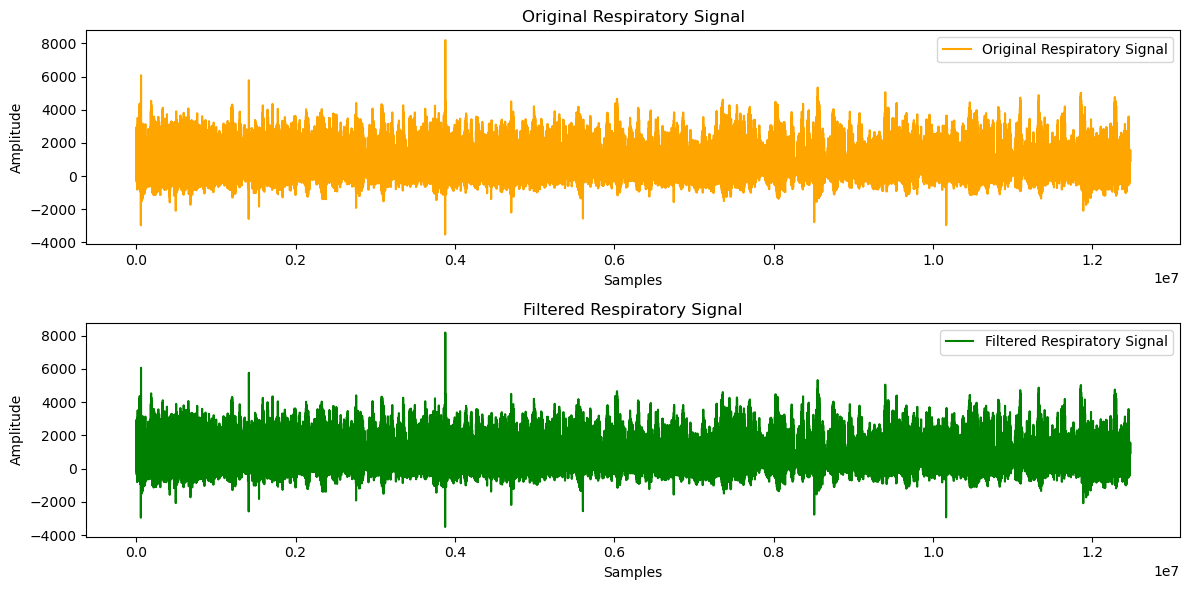


Number of NaN values in filtered signal: 0
Number of NaN values in original signal: 0
Indices of NaN values in filtered signal: []
Indices of NaN values in original signal: []


In [206]:
# small plot before and after filtering
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(resp, label='Original Respiratory Signal', color='orange')
plt.title('Original Respiratory Signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(filtered_resp, label='Filtered Respiratory Signal', color='green')
plt.title('Filtered Respiratory Signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.show()
# Check for NaN values in the filtered signal
nan_indices = np.where(np.isnan(filtered_resp))[0]
# check Nan values in original signal
nan_indices_orig = np.where(np.isnan(resp))[0]
print(f"\nNumber of NaN values in filtered signal: {np.sum(np.isnan(filtered_resp))}")
print(f"Number of NaN values in original signal: {np.sum(np.isnan(resp))}")
print(f"Indices of NaN values in filtered signal: {nan_indices}")
print(f"Indices of NaN values in original signal: {nan_indices_orig}")
